# Binary classification: 1 sigmoid output vs 2 BCE outputs vs 2 softmax outputs

This notebook is prepared for an **AI Engineering** lesson.

We will compare three implementations on the **same binary classification dataset**:

1. **Correct binary formulation:** one neuron with 2 inputs, trained with **BCEWithLogitsLoss**
2. **Wrong probability formulation for mutually exclusive classes:** 2 output neurons, trained with **BCEWithLogitsLoss**
3. **Correct 2-output formulation:** 2 output neurons, trained with **CrossEntropyLoss**  
   (conceptually: logits → softmax probabilities)

## Learning goal

The important point is **not only accuracy**.  
The main goal is to show the difference between:

- **independent sigmoid outputs** (multi-label logic)
- **softmax outputs** (mutually exclusive class logic)

In a binary problem with exactly one true class per sample:

- the **1-output sigmoid model** is correct
- the **2-output softmax model** is also correct
- the **2-output BCE model** is **not the right probability model**, because its two output probabilities are **not forced to sum to 1**

## Google Colab / runtime setup

This notebook runs in **Google Colab** and automatically uses a CUDA GPU if available.  
For this tiny dataset the runtime is fast even on CPU.

In [ ]:

# Cell 1 - Imports, seed, and device selection

%matplotlib inline

import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


## 1. Create a simple binary dataset with 2 input features

We deliberately use a **simple 2D dataset** so the models are easy to visualize.

- Input dimension: **2**
- Output classes: **0 or 1**
- Train/test split: **75% / 25%**

In [ ]:

# Cell 2 - Create and standardize a simple binary dataset

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.1,
    random_state=SEED
)

scaler = StandardScaler()
X = scaler.fit_transform(X).astype(np.float32)
y = y.astype(np.int64)

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

X_train = torch.tensor(X_train_np, dtype=torch.float32, device=DEVICE)
X_test  = torch.tensor(X_test_np, dtype=torch.float32, device=DEVICE)
y_train = torch.tensor(y_train_np, dtype=torch.long, device=DEVICE)
y_test  = torch.tensor(y_test_np, dtype=torch.long, device=DEVICE)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Class balance in train:", np.bincount(y_train_np))
print("Class balance in test: ", np.bincount(y_test_np))

X_train shape: torch.Size([375, 2])
X_test shape:  torch.Size([125, 2])
Class balance in train: [187 188]
Class balance in test:  [62 63]


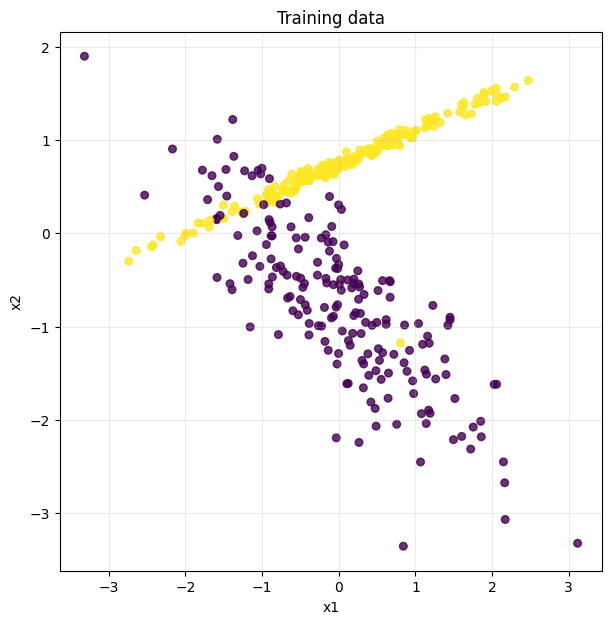

In [ ]:

# Cell 3 - Visualize the dataset

plt.figure(figsize=(7, 7))
plt.scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, s=30, alpha=0.8)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Training data")
plt.grid(True, alpha=0.25)
plt.show()

## 2. The three models

### Model A: one output neuron + BCEWithLogitsLoss

This is the standard setup for binary classification with a single logit:

$$
z = w_1 x_1 + w_2 x_2 + b
$$

We convert that logit into the probability of class 1 using the sigmoid function:

$$
p(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Since there are only two classes, the probability of class 0 is:

$$
p(y=0 \mid x) = 1 - p(y=1 \mid x)
$$

Therefore, the two class probabilities automatically satisfy:

$$
p(y=0 \mid x) + p(y=1 \mid x) = 1
$$

---

### Model B: two output neurons + BCEWithLogitsLoss

Here the network produces two separate logits:

$$
z_0,\; z_1
$$

Then an independent sigmoid is applied to each output:

$$
p_0 = \sigma(z_0), \qquad p_1 = \sigma(z_1)
$$

So each output is treated as an independent yes/no prediction.

That is appropriate for **multi-label classification**, where multiple classes may be true at the same time.

But for a mutually exclusive binary classification problem, this is not the right probabilistic setup, because nothing forces the two outputs to be complementary. In particular, there is no constraint that

$$
p_0 + p_1 = 1
$$

So it is possible to get, for example, both outputs near 1, or both outputs near 0.

---

### Model C: two output neurons + softmax / CrossEntropyLoss

Again the network produces two logits:

$$
z_0,\; z_1
$$

Now we convert them to probabilities using softmax:

$$
p_k = \frac{e^{z_k}}{e^{z_0} + e^{z_1}}, \qquad k \in \{0,1\}
$$

So explicitly,

$$
p_0 = \frac{e^{z_0}}{e^{z_0} + e^{z_1}}, \qquad
p_1 = \frac{e^{z_1}}{e^{z_0} + e^{z_1}}
$$

Now the two probabilities are coupled, which guarantees that for every sample:

$$
p_0 + p_1 = 1
$$

This is the correct formulation when the sample must belong to exactly one of the two classes.

In PyTorch, the usual implementation is to pass the raw logits directly into `CrossEntropyLoss`.  
That loss applies the softmax logic internally in a numerically stable way.

In [ ]:
# Cell 4 - Define the three models

class OneNeuronBinaryClassifier(nn.Module):
    # 2 inputs -> 1 logit
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        return self.linear(x).squeeze(1)   # shape: [batch]


class TwoOutputBCEClassifier(nn.Module):
    # 2 inputs -> 2 logits, then independent sigmoid probabilities
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 2)

    def forward(self, x):
        return self.linear(x)              # shape: [batch, 2]


class TwoOutputSoftmaxClassifier(nn.Module):
    # 2 inputs -> 2 logits, then softmax probabilities
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 2)

    def forward(self, x):
        return self.linear(x)              # shape: [batch, 2]


model_a = OneNeuronBinaryClassifier().to(DEVICE)
model_b = TwoOutputBCEClassifier().to(DEVICE)
model_c = TwoOutputSoftmaxClassifier().to(DEVICE)

print(model_a)
print(model_b)
print(model_c)

OneNeuronBinaryClassifier(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)
TwoOutputBCEClassifier(
  (linear): Linear(in_features=2, out_features=2, bias=True)
)
TwoOutputSoftmaxClassifier(
  (linear): Linear(in_features=2, out_features=2, bias=True)
)


## 3. Training helpers

In [ ]:

# Cell 5 - Training and evaluation helpers

def train_model(model, mode, X_train, y_train, epochs=250, lr=0.1):
    '''
    mode:
        "single_bce" -> one output + BCEWithLogitsLoss
        "two_bce"    -> two outputs + BCEWithLogitsLoss on one-hot targets
        "two_ce"     -> two outputs + CrossEntropyLoss
    '''
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    if mode == "single_bce":
        loss_fn = nn.BCEWithLogitsLoss()
    elif mode == "two_bce":
        loss_fn = nn.BCEWithLogitsLoss()
        y_train_onehot = F.one_hot(y_train, num_classes=2).float()
    elif mode == "two_ce":
        loss_fn = nn.CrossEntropyLoss()
    else:
        raise ValueError("Unknown mode")

    history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        logits = model(X_train)

        if mode == "single_bce":
            loss = loss_fn(logits, y_train.float())
        elif mode == "two_bce":
            loss = loss_fn(logits, y_train_onehot)
        else:
            loss = loss_fn(logits, y_train)

        loss.backward()
        optimizer.step()

        history.append(loss.item())

    return history


@torch.no_grad()
def get_probabilities(model, mode, X):
    model.eval()
    logits = model(X)

    if mode == "single_bce":
        p1 = torch.sigmoid(logits)
        probs = torch.stack([1 - p1, p1], dim=1)
    elif mode == "two_bce":
        probs = torch.sigmoid(logits)
    elif mode == "two_ce":
        probs = torch.softmax(logits, dim=1)
    else:
        raise ValueError("Unknown mode")

    return logits, probs


@torch.no_grad()
def accuracy_from_probabilities(probs, y_true):
    preds = probs.argmax(dim=1)
    return (preds == y_true).float().mean().item()


@torch.no_grad()
def probability_sum_stats(probs):
    s = probs.sum(dim=1)
    return {
        "min": float(s.min().cpu()),
        "max": float(s.max().cpu()),
        "mean": float(s.mean().cpu())
    }

## 4. Train the three models

In [ ]:

# Cell 6 - Train all three models

EPOCHS = 250
LR = 0.10

history_a = train_model(model_a, "single_bce", X_train, y_train, epochs=EPOCHS, lr=LR)
history_b = train_model(model_b, "two_bce",    X_train, y_train, epochs=EPOCHS, lr=LR)
history_c = train_model(model_c, "two_ce",     X_train, y_train, epochs=EPOCHS, lr=LR)

print("Training finished.")

Training finished.


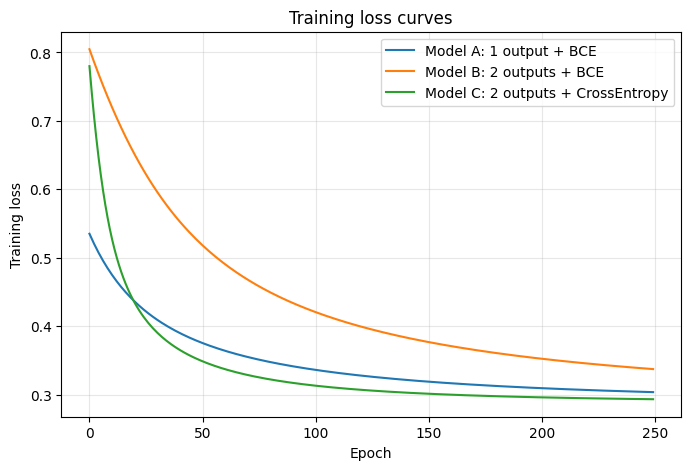

In [ ]:

# Cell 7 - Plot training losses

plt.figure(figsize=(8, 5))
plt.plot(history_a, label="Model A: 1 output + BCE")
plt.plot(history_b, label="Model B: 2 outputs + BCE")
plt.plot(history_c, label="Model C: 2 outputs + CrossEntropy")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training loss curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5. Compare the models on the test set

In [ ]:

# Cell 8 - Evaluate on the test set

_, probs_a_test = get_probabilities(model_a, "single_bce", X_test)
_, probs_b_test = get_probabilities(model_b, "two_bce",    X_test)
_, probs_c_test = get_probabilities(model_c, "two_ce",     X_test)

acc_a = accuracy_from_probabilities(probs_a_test, y_test)
acc_b = accuracy_from_probabilities(probs_b_test, y_test)
acc_c = accuracy_from_probabilities(probs_c_test, y_test)

stats_a_test = probability_sum_stats(probs_a_test)
stats_b_test = probability_sum_stats(probs_b_test)
stats_c_test = probability_sum_stats(probs_c_test)

comparison_df = pd.DataFrame([
    {
        "Model": "A - 1 output + BCE",
        "Test accuracy": acc_a,
        "Probability sum min (test)": stats_a_test["min"],
        "Probability sum max (test)": stats_a_test["max"],
        "Probability sum mean (test)": stats_a_test["mean"],
        "Guaranteed sum to 1?": "Yes"
    },
    {
        "Model": "B - 2 outputs + BCE",
        "Test accuracy": acc_b,
        "Probability sum min (test)": stats_b_test["min"],
        "Probability sum max (test)": stats_b_test["max"],
        "Probability sum mean (test)": stats_b_test["mean"],
        "Guaranteed sum to 1?": "No"
    },
    {
        "Model": "C - 2 outputs + softmax / CE",
        "Test accuracy": acc_c,
        "Probability sum min (test)": stats_c_test["min"],
        "Probability sum max (test)": stats_c_test["max"],
        "Probability sum mean (test)": stats_c_test["mean"],
        "Guaranteed sum to 1?": "Yes"
    }
])

comparison_df

,Model,Test accuracy,Probability sum min (test),Probability sum max (test),Probability sum mean (test),Guaranteed sum to 1?
0,A - 1 output + BCE,0.896,1.000000,1.000000,1.00000,Yes
1,B - 2 outputs + BCE,0.896,0.962393,1.074907,1.01325,No
2,C - 2 outputs + softmax / CE,0.896,1.000000,1.000000,1.00000,Yes


### Important observation

On an easy in-distribution test set, the wrong model (**2 outputs + BCE**) may still get good accuracy, and its probability sums may even look close to 1.

That **does not make the formulation correct**.

The real difference is structural:

- **Model B** uses two **independent** sigmoids
- **Model C** uses a **coupled** normalization via softmax

So next we will inspect that difference more directly.

In [ ]:

# Cell 9 - Show a few example predictions on the test set

n_show = 10

table = pd.DataFrame({
    "true_y": y_test.detach().cpu().numpy()[:n_show],
    "A_p(class0)": probs_a_test[:, 0].detach().cpu().numpy()[:n_show],
    "A_p(class1)": probs_a_test[:, 1].detach().cpu().numpy()[:n_show],
    "A_sum": probs_a_test.sum(dim=1).detach().cpu().numpy()[:n_show],
    "B_p(class0)": probs_b_test[:, 0].detach().cpu().numpy()[:n_show],
    "B_p(class1)": probs_b_test[:, 1].detach().cpu().numpy()[:n_show],
    "B_sum": probs_b_test.sum(dim=1).detach().cpu().numpy()[:n_show],
    "C_p(class0)": probs_c_test[:, 0].detach().cpu().numpy()[:n_show],
    "C_p(class1)": probs_c_test[:, 1].detach().cpu().numpy()[:n_show],
    "C_sum": probs_c_test.sum(dim=1).detach().cpu().numpy()[:n_show],
})

table.round(4)

,true_y,A_p(class0),A_p(class1),A_sum,B_p(class0),B_p(class1),B_sum,C_p(class0),C_p(class1),C_sum
0,1,0.0379,0.9621,1.0,0.0914,0.9191,1.0105,0.0239,0.9761,1.0
1,0,0.6397,0.3603,1.0,0.6055,0.4237,1.0292,0.6774,0.3226,1.0
2,1,0.1115,0.8885,1.0,0.1845,0.8313,1.0158,0.0862,0.9138,1.0
3,1,0.0789,0.9211,1.0,0.1478,0.8665,1.0143,0.0571,0.9429,1.0
4,0,0.6808,0.3192,1.0,0.6694,0.3973,1.0668,0.7323,0.2677,1.0
5,1,0.0507,0.9493,1.0,0.1108,0.9012,1.0120,0.0338,0.9662,1.0
6,1,0.3833,0.6167,1.0,0.3916,0.6056,0.9972,0.3716,0.6284,1.0
7,0,0.9770,0.0230,1.0,0.9548,0.0734,1.0282,0.9898,0.0102,1.0
8,0,0.9751,0.0249,1.0,0.9485,0.0765,1.0249,0.9885,0.0115,1.0
9,0,0.7637,0.2363,1.0,0.6909,0.3217,1.0126,0.8059,0.1941,1.0


## 6. A direct conceptual demonstration with hand-crafted logits

This cell is extremely important pedagogically.

Suppose a model outputs two logits for a binary problem.

If we apply **independent sigmoids** to `[4, 4]`, we get approximately:

- `sigmoid(4) ≈ 0.982`
- `sigmoid(4) ≈ 0.982`

So the model can say:

- class 0 probability ≈ 0.982
- class 1 probability ≈ 0.982

These clearly **do not form a valid mutually exclusive probability distribution**.

But with **softmax** on `[4, 4]`, we get:

- `[0.5, 0.5]`

and the two probabilities **must sum to 1**.

In [ ]:

# Cell 10 - Hand-crafted logits demo: sigmoid vs softmax

toy_logits = torch.tensor([
    [ 4.0,  4.0],   # both large positive
    [ 4.0, -4.0],   # class 0 strongly larger
    [ 0.0,  0.0],   # tie
    [-4.0, -4.0],   # both large negative
], dtype=torch.float32)

toy_sigmoid = torch.sigmoid(toy_logits)
toy_softmax = torch.softmax(toy_logits, dim=1)

toy_df = pd.DataFrame({
    "z0": toy_logits[:, 0].numpy(),
    "z1": toy_logits[:, 1].numpy(),
    "sigmoid_p0": toy_sigmoid[:, 0].numpy(),
    "sigmoid_p1": toy_sigmoid[:, 1].numpy(),
    "sigmoid_sum": toy_sigmoid.sum(dim=1).numpy(),
    "softmax_p0": toy_softmax[:, 0].numpy(),
    "softmax_p1": toy_softmax[:, 1].numpy(),
    "softmax_sum": toy_softmax.sum(dim=1).numpy(),
})

toy_df.round(4)

,z0,z1,sigmoid_p0,sigmoid_p1,sigmoid_sum,softmax_p0,softmax_p1,softmax_sum
0,4.0,4.0,0.982,0.982,1.964,0.5000,0.5000,1.0
1,4.0,-4.0,0.982,0.018,1.000,0.9997,0.0003,1.0
2,0.0,0.0,0.500,0.500,1.000,0.5000,0.5000,1.0
3,-4.0,-4.0,0.018,0.018,0.036,0.5000,0.5000,1.0


## 7. Inspect the probability sums on a **wide probe region**

To make the structural difference visible, we evaluate the trained models not only on the test set, but also on a **much wider 2D region** than the training data.

This often reveals the issue clearly:

- **Model B (2 outputs + BCE)** can produce sums **below 1** or **above 1**
- **Model C (softmax / CE)** always produces sums exactly equal to 1
- **Model A** also always sums to 1 because we construct `[1-p, p]`

In [ ]:

# Cell 11 - Create a wide probe grid

wide_factor = 6.0

x0_abs = max(abs(X[:, 0].min()), abs(X[:, 0].max()))
x1_abs = max(abs(X[:, 1].min()), abs(X[:, 1].max()))

x0_vals = np.linspace(-wide_factor * x0_abs, wide_factor * x0_abs, 180)
x1_vals = np.linspace(-wide_factor * x1_abs, wide_factor * x1_abs, 180)

xx0, xx1 = np.meshgrid(x0_vals, x1_vals)
grid_np = np.c_[xx0.ravel(), xx1.ravel()].astype(np.float32)
grid = torch.tensor(grid_np, dtype=torch.float32, device=DEVICE)

_, probs_a_grid = get_probabilities(model_a, "single_bce", grid)
_, probs_b_grid = get_probabilities(model_b, "two_bce",    grid)
_, probs_c_grid = get_probabilities(model_c, "two_ce",     grid)

sum_a_grid = probs_a_grid.sum(dim=1).detach().cpu().numpy().reshape(xx0.shape)
sum_b_grid = probs_b_grid.sum(dim=1).detach().cpu().numpy().reshape(xx0.shape)
sum_c_grid = probs_c_grid.sum(dim=1).detach().cpu().numpy().reshape(xx0.shape)

grid_stats_df = pd.DataFrame([
    {
        "Model": "A - 1 output + BCE",
        "Wide-grid sum min": float(sum_a_grid.min()),
        "Wide-grid sum max": float(sum_a_grid.max()),
        "Wide-grid sum mean": float(sum_a_grid.mean()),
    },
    {
        "Model": "B - 2 outputs + BCE",
        "Wide-grid sum min": float(sum_b_grid.min()),
        "Wide-grid sum max": float(sum_b_grid.max()),
        "Wide-grid sum mean": float(sum_b_grid.mean()),
    },
    {
        "Model": "C - 2 outputs + softmax / CE",
        "Wide-grid sum min": float(sum_c_grid.min()),
        "Wide-grid sum max": float(sum_c_grid.max()),
        "Wide-grid sum mean": float(sum_c_grid.mean()),
    },
])

grid_stats_df.round(4)

,Model,Wide-grid sum min,Wide-grid sum max,Wide-grid sum mean
0,A - 1 output + BCE,1.0000,1.0000,1.0000
1,B - 2 outputs + BCE,0.4498,1.5959,1.0019
2,C - 2 outputs + softmax / CE,1.0000,1.0000,1.0000


In [ ]:

# Cell 12 - Count how often the probability sum deviates from 1 on the wide grid

def count_deviations(sum_grid, low=0.9, high=1.1):
    flat = sum_grid.ravel()
    return {
        "count_below_low": int((flat < low).sum()),
        "count_above_high": int((flat > high).sum()),
        "count_total": int(flat.size)
    }

print("Model A:", count_deviations(sum_a_grid))
print("Model B:", count_deviations(sum_b_grid))
print("Model C:", count_deviations(sum_c_grid))

Model A: {'count_below_low': 0, 'count_above_high': 0, 'count_total': 32400}
Model B: {'count_below_low': 829, 'count_above_high': 986, 'count_total': 32400}
Model C: {'count_below_low': 0, 'count_above_high': 0, 'count_total': 32400}


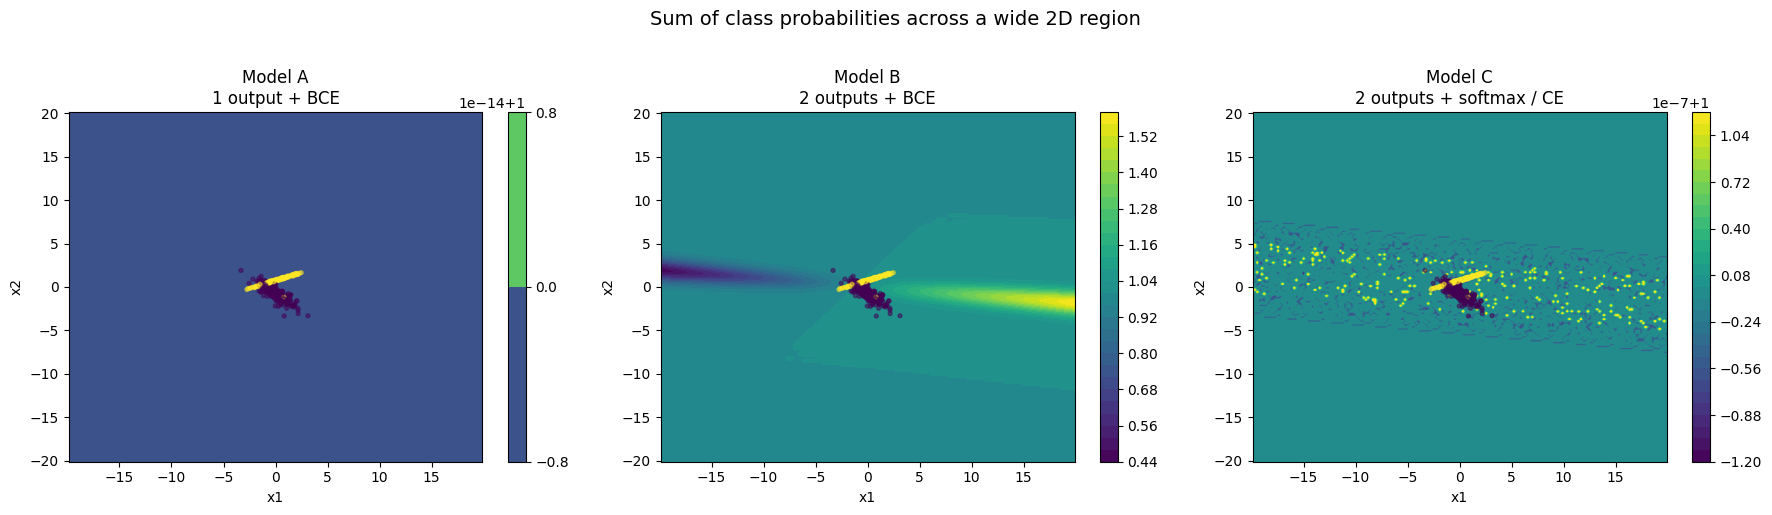

In [ ]:

# Cell 13 - Visualize the probability-sum field for each model

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

images = [
    (sum_a_grid, "Model A\n1 output + BCE"),
    (sum_b_grid, "Model B\n2 outputs + BCE"),
    (sum_c_grid, "Model C\n2 outputs + softmax / CE"),
]

for ax, (img, title) in zip(axes, images):
    im = ax.contourf(xx0, xx1, img, levels=30)
    ax.scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, s=8, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    plt.colorbar(im, ax=ax)

plt.suptitle("Sum of class probabilities across a wide 2D region", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 8. Decision-region comparison

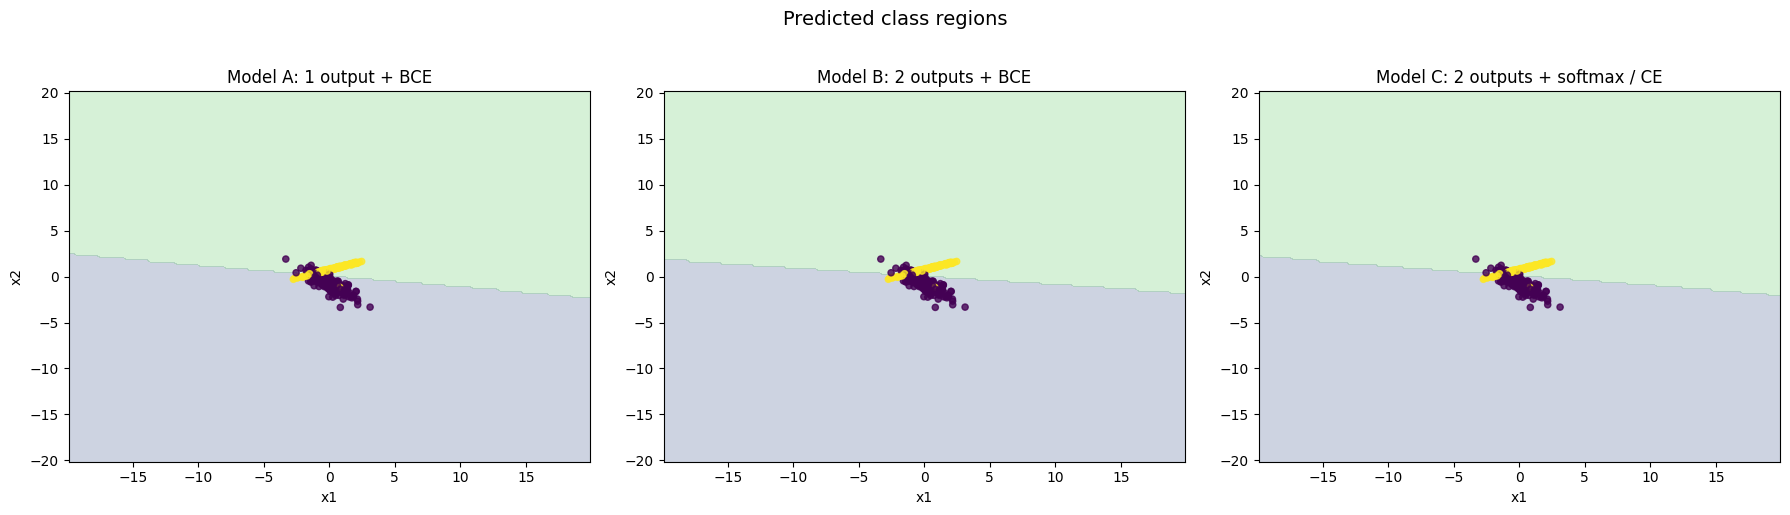

In [ ]:

# Cell 14 - Plot predicted classes for the three models

@torch.no_grad()
def predicted_class_grid(model, mode, grid):
    _, probs = get_probabilities(model, mode, grid)
    preds = probs.argmax(dim=1).detach().cpu().numpy()
    return preds.reshape(xx0.shape)

pred_a = predicted_class_grid(model_a, "single_bce", grid)
pred_b = predicted_class_grid(model_b, "two_bce",    grid)
pred_c = predicted_class_grid(model_c, "two_ce",     grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pred, title in zip(
    axes,
    [pred_a, pred_b, pred_c],
    [
        "Model A: 1 output + BCE",
        "Model B: 2 outputs + BCE",
        "Model C: 2 outputs + softmax / CE"
    ]
):
    ax.contourf(xx0, xx1, pred, alpha=0.25, levels=[-0.5, 0.5, 1.5])
    ax.scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, s=20, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.suptitle("Predicted class regions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 9. Final conclusions

### What we learned

**Model A: 1 output + BCEWithLogitsLoss**
- Correct for binary classification
- Uses one logit for class 1
- Class 0 probability is `1 - p`
- Probabilities sum to 1

**Model B: 2 outputs + BCEWithLogitsLoss**
- Not the correct probability model for a mutually exclusive 2-class problem
- Treats the outputs as independent yes/no labels
- Probabilities are **not constrained** to sum to 1
- Can still achieve good accuracy on easy data, but the probabilistic interpretation is wrong

**Model C: 2 outputs + softmax / CrossEntropyLoss**
- Correct for mutually exclusive classes
- The two outputs compete with each other
- Probabilities are normalized and sum to 1

### Practical recommendation

For a binary problem with exactly one true class per sample, use either:

1. **one output + BCEWithLogitsLoss**
2. **two outputs + CrossEntropyLoss**

Do **not** use **two outputs + BCEWithLogitsLoss** if you want a proper mutually exclusive class probability model.